### CNN_LSTM_Hybrid

In [ ]:
import os
import numpy as np
import torch
from torch.utils.data import DataLoader
from datasets import EEGDataset
from models import CNN_LSTM_Hybrid, LConvNet, CNN_LSTM_Hybrid_Final
from train import train_model
from evaluate import evaluate_on_test, evaluate
import torch.nn as nn
import torch.optim as optim

In [ ]:
# 설정 
data_dir = './DATA'
save_model_dir = './saved_models'
os.makedirs(save_model_dir, exist_ok=True)

batch_size = 128
epochs = 50
learning_rate = 0.001
input_shape = (12, 256)  # 12채널, 256포인트 (2초 @ 128Hz)

In [ ]:
# 데이터 로딩
X_train = np.load(os.path.join(data_dir, "multi_X_train.npy"))
X_val   = np.load(os.path.join(data_dir, "multi_X_val.npy"))
X_test  = np.load(os.path.join(data_dir, "multi_X_test.npy"))
y_train = np.load(os.path.join(data_dir, "multi_y_train.npy"))
y_val   = np.load(os.path.join(data_dir, "multi_y_val.npy"))
y_test  = np.load(os.path.join(data_dir, "multi_y_test.npy"))

train_loader = DataLoader(EEGDataset(X_train, y_train), batch_size=batch_size, shuffle=True)
val_loader   = DataLoader(EEGDataset(X_val, y_val), batch_size=batch_size, shuffle=False)
test_loader  = DataLoader(EEGDataset(X_test, y_test), batch_size=batch_size, shuffle=False)

In [ ]:
# 모델 1: CNN_LSTM_Hybrid 
# 디바이스, 손실함수, 옵티마이저 설정
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model1 = CNN_LSTM_Hybrid().to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model1.parameters(), lr=learning_rate)

Epoch 1/50: 100%|██████████| 169/169 [00:57<00:00,  2.96it/s, loss=0.474]



[Epoch 1]
Train Loss  : 0.6399
Val Loss    : 0.5315
Train Acc   : 0.6303 | Val Acc : 0.7501
Train F1    : 0.6410 | Val F1  : 0.7613
Train Rec   : 0.6751 | Val Rec : 0.8152
Train Prec  : 0.6102 | Val Prec: 0.7142
✅ Best model saved: CNN_LSTM_Hybrid_acc_0.7501.pt


Epoch 2/50: 100%|██████████| 169/169 [00:59<00:00,  2.84it/s, loss=0.308]



[Epoch 2]
Train Loss  : 0.4983
Val Loss    : 0.6191
Train Acc   : 0.7689 | Val Acc : 0.7074
Train F1    : 0.7665 | Val F1  : 0.5994
Train Rec   : 0.7758 | Val Rec : 0.4477
Train Prec  : 0.7575 | Val Prec: 0.9066
⏳ EarlyStopping patience: 1/7


Epoch 3/50: 100%|██████████| 169/169 [01:41<00:00,  1.66it/s, loss=0.594]


...


[Epoch 16]
Train Loss  : 0.2367
Val Loss    : 0.9578
Train Acc   : 0.9076 | Val Acc : 0.6411
Train F1    : 0.9073 | Val F1  : 0.7305
Train Rec   : 0.9249 | Val Rec : 0.9947
Train Prec  : 0.8905 | Val Prec: 0.5772
⏳ EarlyStopping patience: 5/7


Epoch 17/50: 100%|██████████| 169/169 [01:06<00:00,  2.55it/s, loss=0.321]



[Epoch 17]
Train Loss  : 0.2245
Val Loss    : 0.8443
Train Acc   : 0.9111 | Val Acc : 0.7540
Train F1    : 0.9110 | Val F1  : 0.6738
Train Rec   : 0.9309 | Val Rec : 0.5195
Train Prec  : 0.8921 | Val Prec: 0.9583
⏳ EarlyStopping patience: 6/7


Epoch 18/50: 100%|██████████| 169/169 [01:30<00:00,  1.86it/s, loss=0.193] 



[Epoch 18]
Train Loss  : 0.2223
Val Loss    : 1.5488
Train Acc   : 0.9109 | Val Acc : 0.6786
Train F1    : 0.9106 | Val F1  : 0.5221
Train Rec   : 0.9283 | Val Rec : 0.3590
Train Prec  : 0.8936 | Val Prec: 0.9563
⏳ EarlyStopping patience: 7/7
Early stopping triggered!


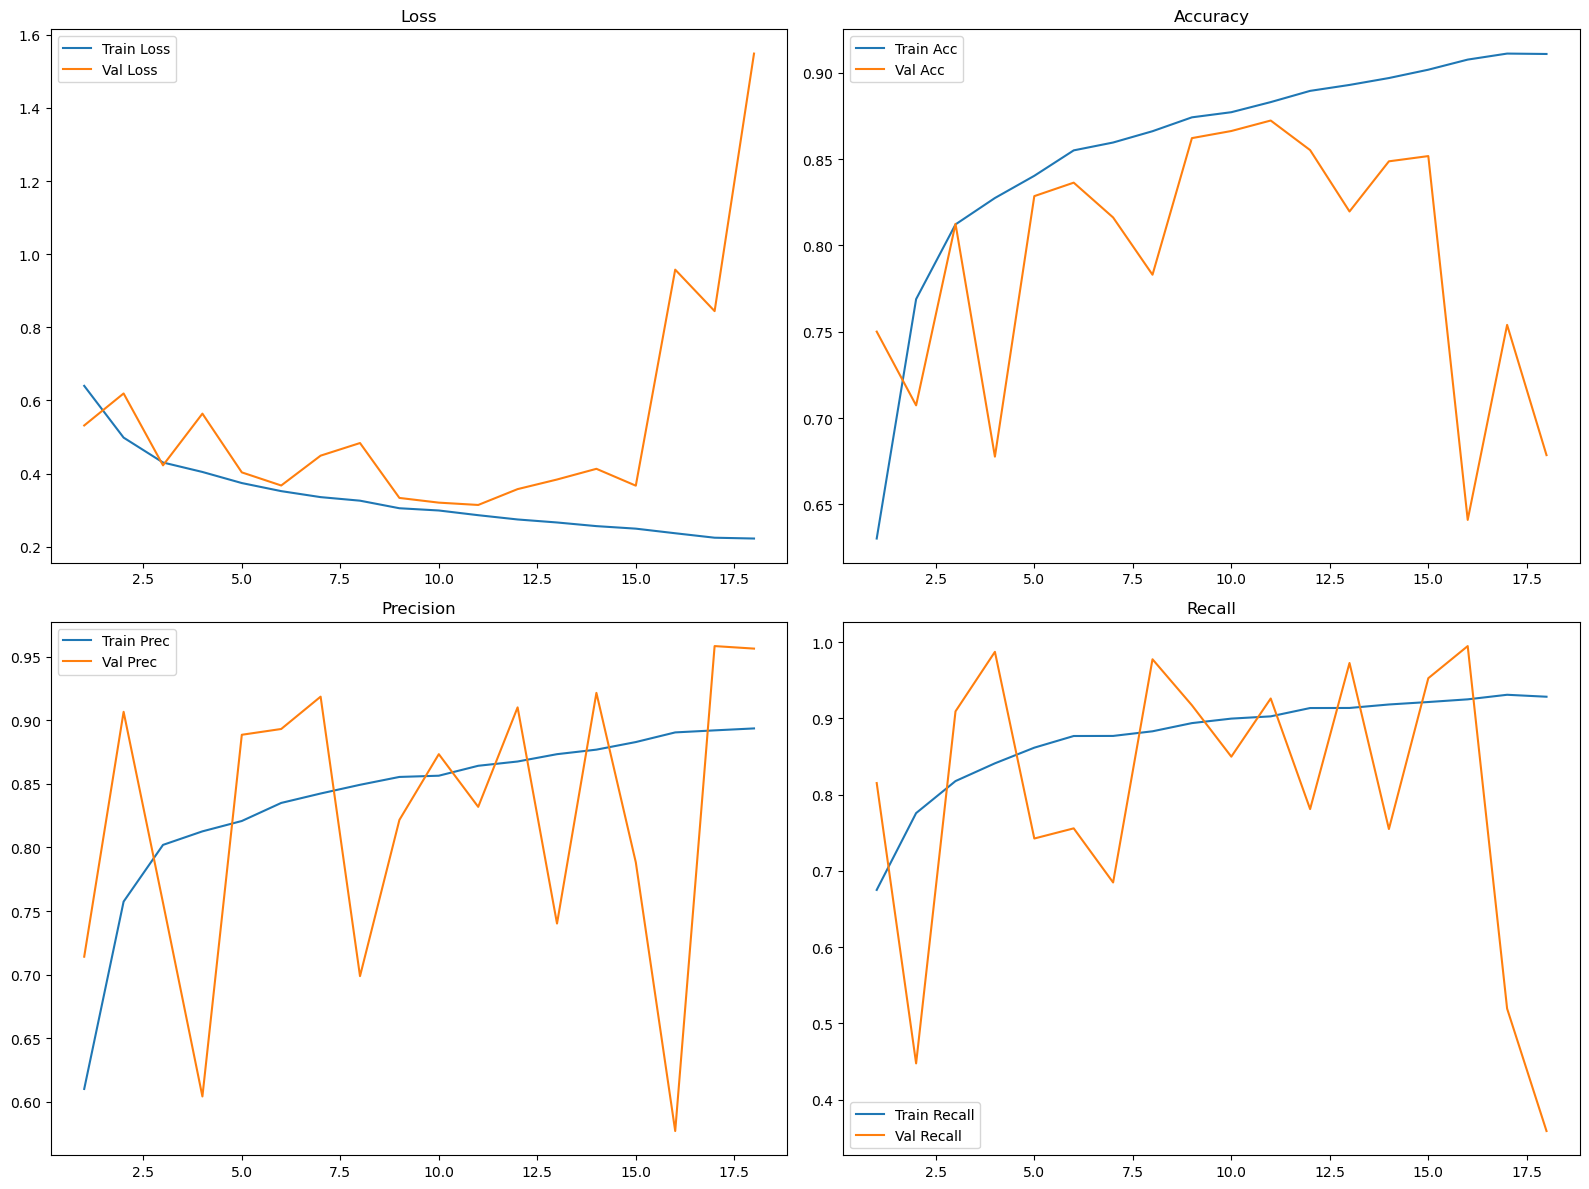

<Figure size 500x400 with 0 Axes>

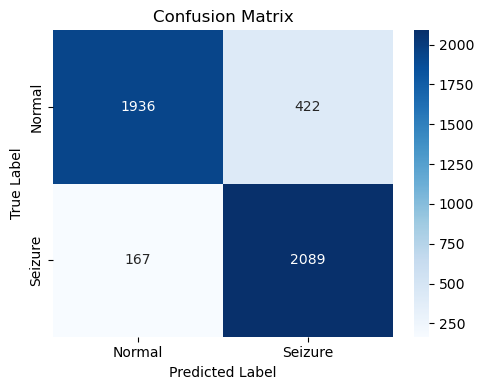

In [5]:
# 학습
model1 = train_model(model1, train_loader, val_loader,
                     criterion, optimizer, device,
                     num_epochs=epochs,
                     model_name="CNN_LSTM_Hybrid",
                     save_model_dir=save_model_dir)


[TEST] CNN_LSTM_Hybrid 결과

[Test Evaluation]
Accuracy  : 0.6795
Precision : 0.9566
Recall    : 0.3611
F1 Score  : 0.5243
Confusion Matrix:
 [[2321   37]
 [1442  815]]


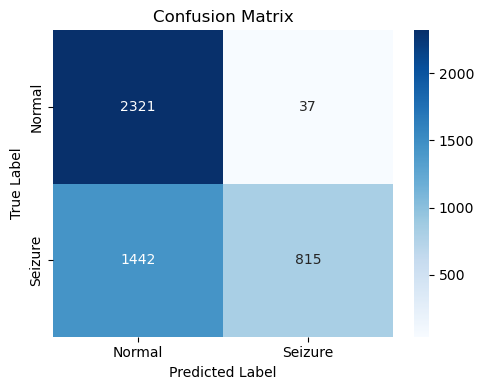

(0.6795232936078006,
 0.9565727699530516,
 0.36109880372175457,
 0.5242843357992923)

In [6]:
# 테스트
print("\n[TEST] CNN_LSTM_Hybrid 결과")
evaluate_on_test(model1, test_loader, device)

### LConvNet

In [7]:
from models import LConvNet

# 모델 정의
model2 = LConvNet(num_channels=12, seq_len=256, num_classes=2)
model2 = model2.to(device)

# 손실함수 및 옵티마이저
criterion2 = nn.CrossEntropyLoss()
optimizer2 = optim.Adam(model2.parameters(), lr=learning_rate)

Epoch 1/50: 100%|██████████| 169/169 [00:57<00:00,  2.95it/s, loss=0.673]



[Epoch 1]
Train Loss  : 0.6847
Val Loss    : 0.6785
Train Acc   : 0.5447 | Val Acc : 0.5704
Train F1    : 0.4703 | Val F1  : 0.6742
Train Rec   : 0.4134 | Val Rec : 0.9091
Train Prec  : 0.5454 | Val Prec: 0.5358
✅ Best model saved: LConvNet_acc_0.5704.pt


Epoch 2/50: 100%|██████████| 169/169 [01:19<00:00,  2.13it/s, loss=0.603]



[Epoch 2]
Train Loss  : 0.6504
Val Loss    : 0.6337
Train Acc   : 0.6220 | Val Acc : 0.6437
Train F1    : 0.6423 | Val F1  : 0.6985
Train Rec   : 0.6941 | Val Rec : 0.8440
Train Prec  : 0.5977 | Val Prec: 0.5957
✅ Best model saved: LConvNet_acc_0.6437.pt


Epoch 3/50: 100%|██████████| 169/169 [00:54<00:00,  3.11it/s, loss=0.605]


...


[Epoch 48]
Train Loss  : 0.2798
Val Loss    : 0.3593
Train Acc   : 0.8834 | Val Acc : 0.8505
Train F1    : 0.8805 | Val F1  : 0.8485
Train Rec   : 0.8783 | Val Rec : 0.8564
Train Prec  : 0.8827 | Val Prec: 0.8407
⏳ EarlyStopping patience: 1/7


Epoch 49/50: 100%|██████████| 169/169 [00:52<00:00,  3.25it/s, loss=0.166]



[Epoch 49]
Train Loss  : 0.2856
Val Loss    : 0.3762
Train Acc   : 0.8825 | Val Acc : 0.8518
Train F1    : 0.8798 | Val F1  : 0.8415
Train Rec   : 0.8797 | Val Rec : 0.8050
Train Prec  : 0.8799 | Val Prec: 0.8816
✅ Best model saved: LConvNet_acc_0.8518.pt


Epoch 50/50: 100%|██████████| 169/169 [00:55<00:00,  3.06it/s, loss=0.185]



[Epoch 50]
Train Loss  : 0.2673
Val Loss    : 0.3420
Train Acc   : 0.8903 | Val Acc : 0.8561
Train F1    : 0.8879 | Val F1  : 0.8510
Train Rec   : 0.8887 | Val Rec : 0.8404
Train Prec  : 0.8872 | Val Prec: 0.8618
✅ Best model saved: LConvNet_acc_0.8561.pt


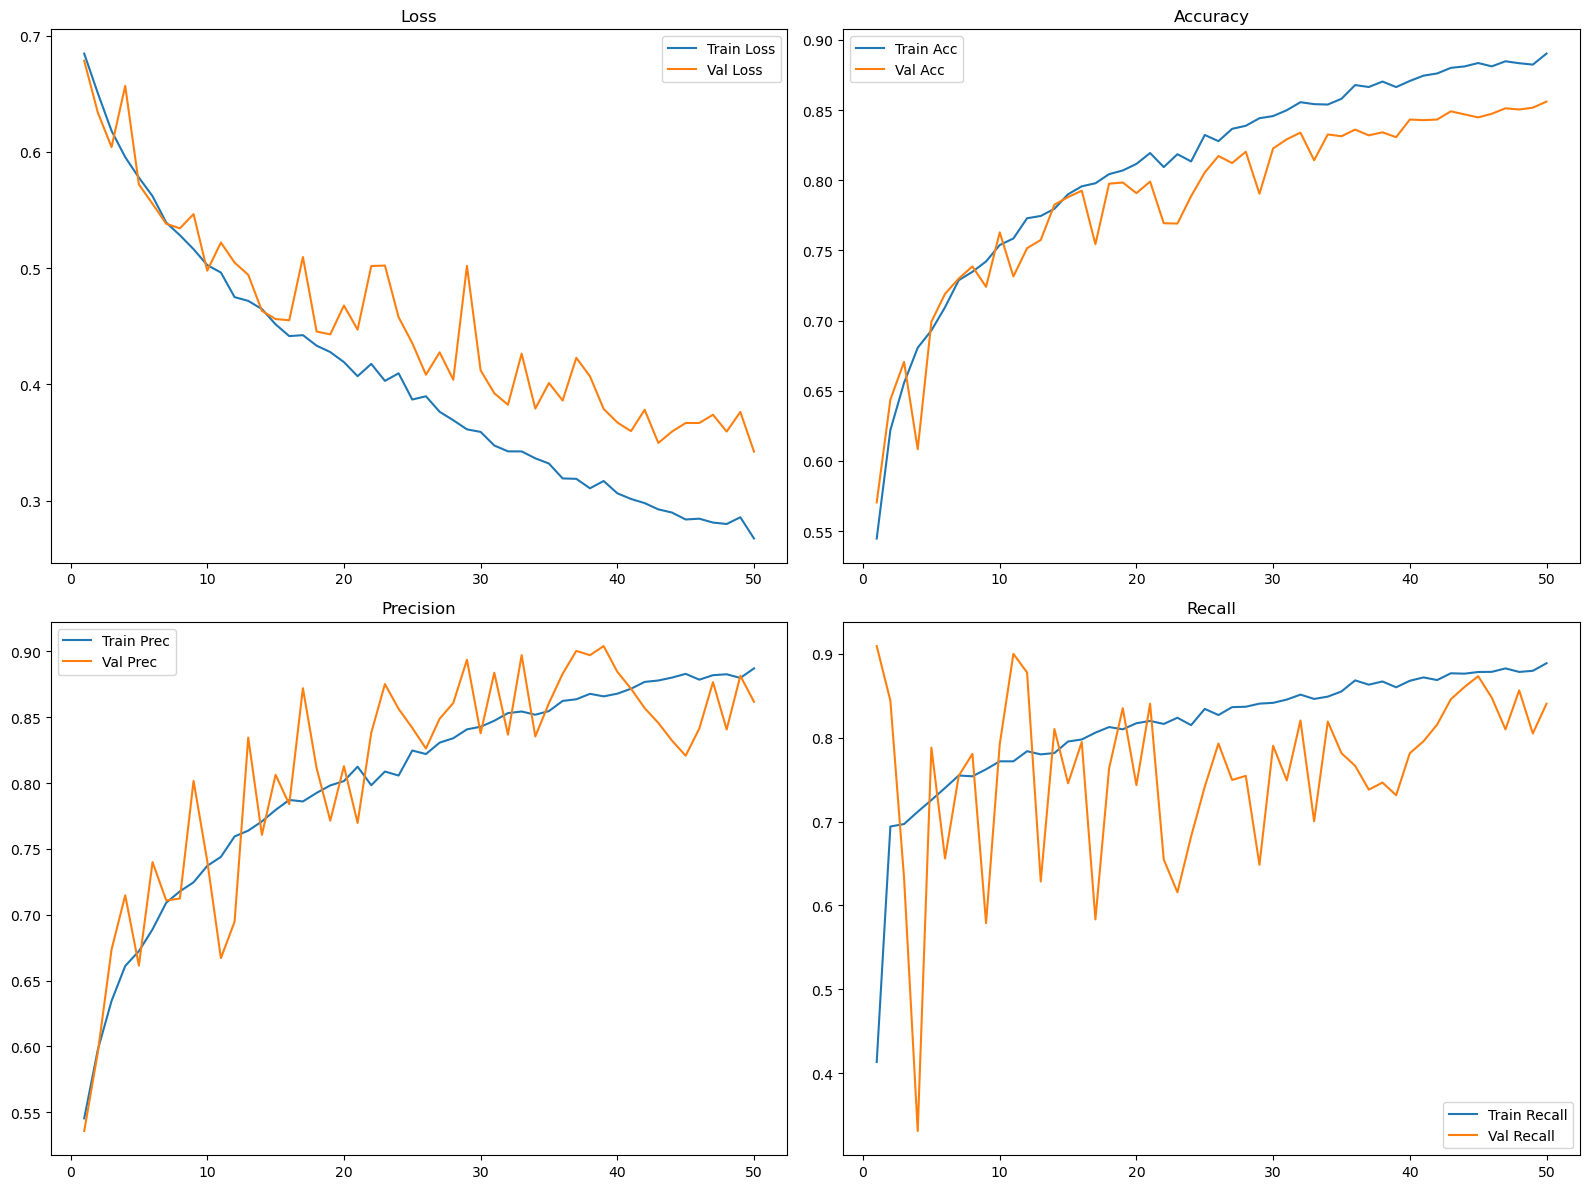

<Figure size 500x400 with 0 Axes>

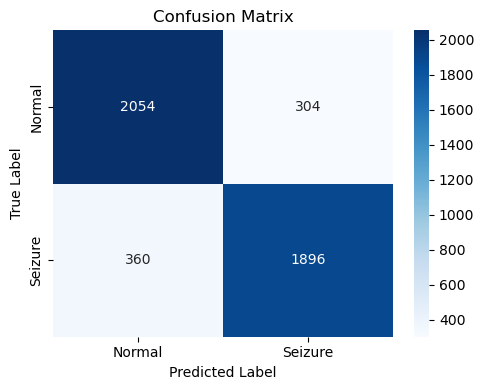

In [8]:
# 학습
model2 = train_model(model2, train_loader, val_loader,
                     criterion=criterion2, optimizer=optimizer2,
                     device=device, num_epochs=epochs,
                     model_name="LConvNet", save_model_dir=save_model_dir)


[TEST] CNN_LSTM_Hybrid 결과

[Test Evaluation]
Accuracy  : 0.6795
Precision : 0.9566
Recall    : 0.3611
F1 Score  : 0.5243
Confusion Matrix:
 [[2321   37]
 [1442  815]]


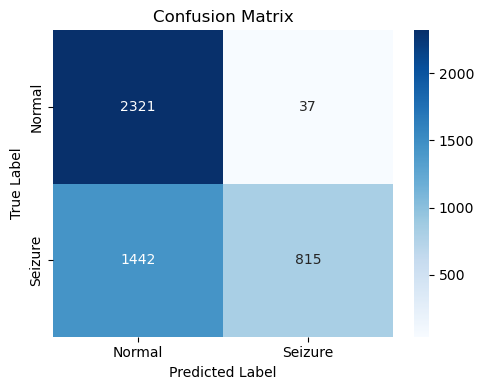

(0.6795232936078006,
 0.9565727699530516,
 0.36109880372175457,
 0.5242843357992923)

In [ ]:
# 테스트
print("\n[TEST] CNN_LSTM_Hybrid 결과")
evaluate_on_test(model2, test_loader, device)


[TEST] LConvNet 결과

[Test Evaluation]
Accuracy  : 0.8449
Precision : 0.8482
Recall    : 0.8316
F1 Score  : 0.8398
Confusion Matrix:
 [[2022  336]
 [ 380 1877]]


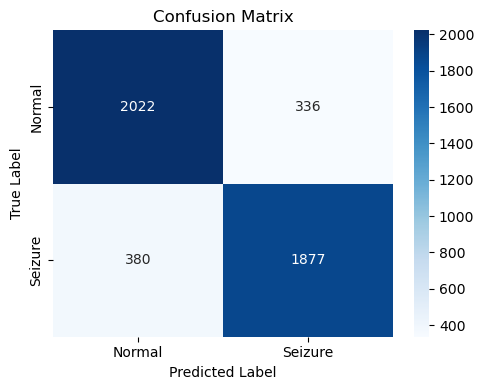

(0.8448537378114843, 0.8481699051061907, 0.8316349136021267, 0.839821029082774)

In [ ]:
# 테스트 평가
print("\n[TEST] LConvNet 결과")
evaluate_on_test(model2, test_loader, device)

In [ ]:
# 모델 3: CNN_LSTM_Hybrid_Final 
model3 = CNN_LSTM_Hybrid_Final().to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model3.parameters(), lr=learning_rate)

Epoch 1/50: 100%|██████████| 169/169 [01:07<00:00,  2.49it/s, loss=0.674]



[Epoch 1]
Train Loss  : 0.6589
Val Loss    : 0.6533
Train Acc   : 0.5913 | Val Acc : 0.6064
Train F1    : 0.4820 | Val F1  : 0.4474
Train Rec   : 0.3889 | Val Rec : 0.3258
Train Prec  : 0.6337 | Val Prec: 0.7136
✅ Best model saved: CNN_LSTM_Hybrid_Final_acc_0.6064.pt


Epoch 2/50: 100%|██████████| 169/169 [01:12<00:00,  2.34it/s, loss=0.634]



[Epoch 2]
Train Loss  : 0.6442
Val Loss    : 0.6433
Train Acc   : 0.6048 | Val Acc : 0.6123
Train F1    : 0.5173 | Val F1  : 0.4372
Train Rec   : 0.4330 | Val Rec : 0.3081
Train Prec  : 0.6423 | Val Prec: 0.7530
✅ Best model saved: CNN_LSTM_Hybrid_Final_acc_0.6123.pt


Epoch 3/50: 100%|██████████| 169/169 [01:45<00:00,  1.60it/s, loss=0.583]


...


[Epoch 33]
Train Loss  : 0.1601
Val Loss    : 0.3160
Train Acc   : 0.9345 | Val Acc : 0.8827
Train F1    : 0.9337 | Val F1  : 0.8886
Train Rec   : 0.9428 | Val Rec : 0.9566
Train Prec  : 0.9247 | Val Prec: 0.8297
⏳ EarlyStopping patience: 5/7


Epoch 34/50: 100%|██████████| 169/169 [01:02<00:00,  2.72it/s, loss=0.0879]



[Epoch 34]
Train Loss  : 0.1360
Val Loss    : 0.4001
Train Acc   : 0.9468 | Val Acc : 0.8840
Train F1    : 0.9459 | Val F1  : 0.8860
Train Rec   : 0.9517 | Val Rec : 0.9215
Train Prec  : 0.9402 | Val Prec: 0.8531
⏳ EarlyStopping patience: 6/7


Epoch 35/50: 100%|██████████| 169/169 [01:08<00:00,  2.45it/s, loss=0.492] 



[Epoch 35]
Train Loss  : 0.1380
Val Loss    : 0.3048
Train Acc   : 0.9452 | Val Acc : 0.8955
Train F1    : 0.9443 | Val F1  : 0.8976
Train Rec   : 0.9515 | Val Rec : 0.9362
Train Prec  : 0.9373 | Val Prec: 0.8620
⏳ EarlyStopping patience: 7/7
Early stopping triggered!


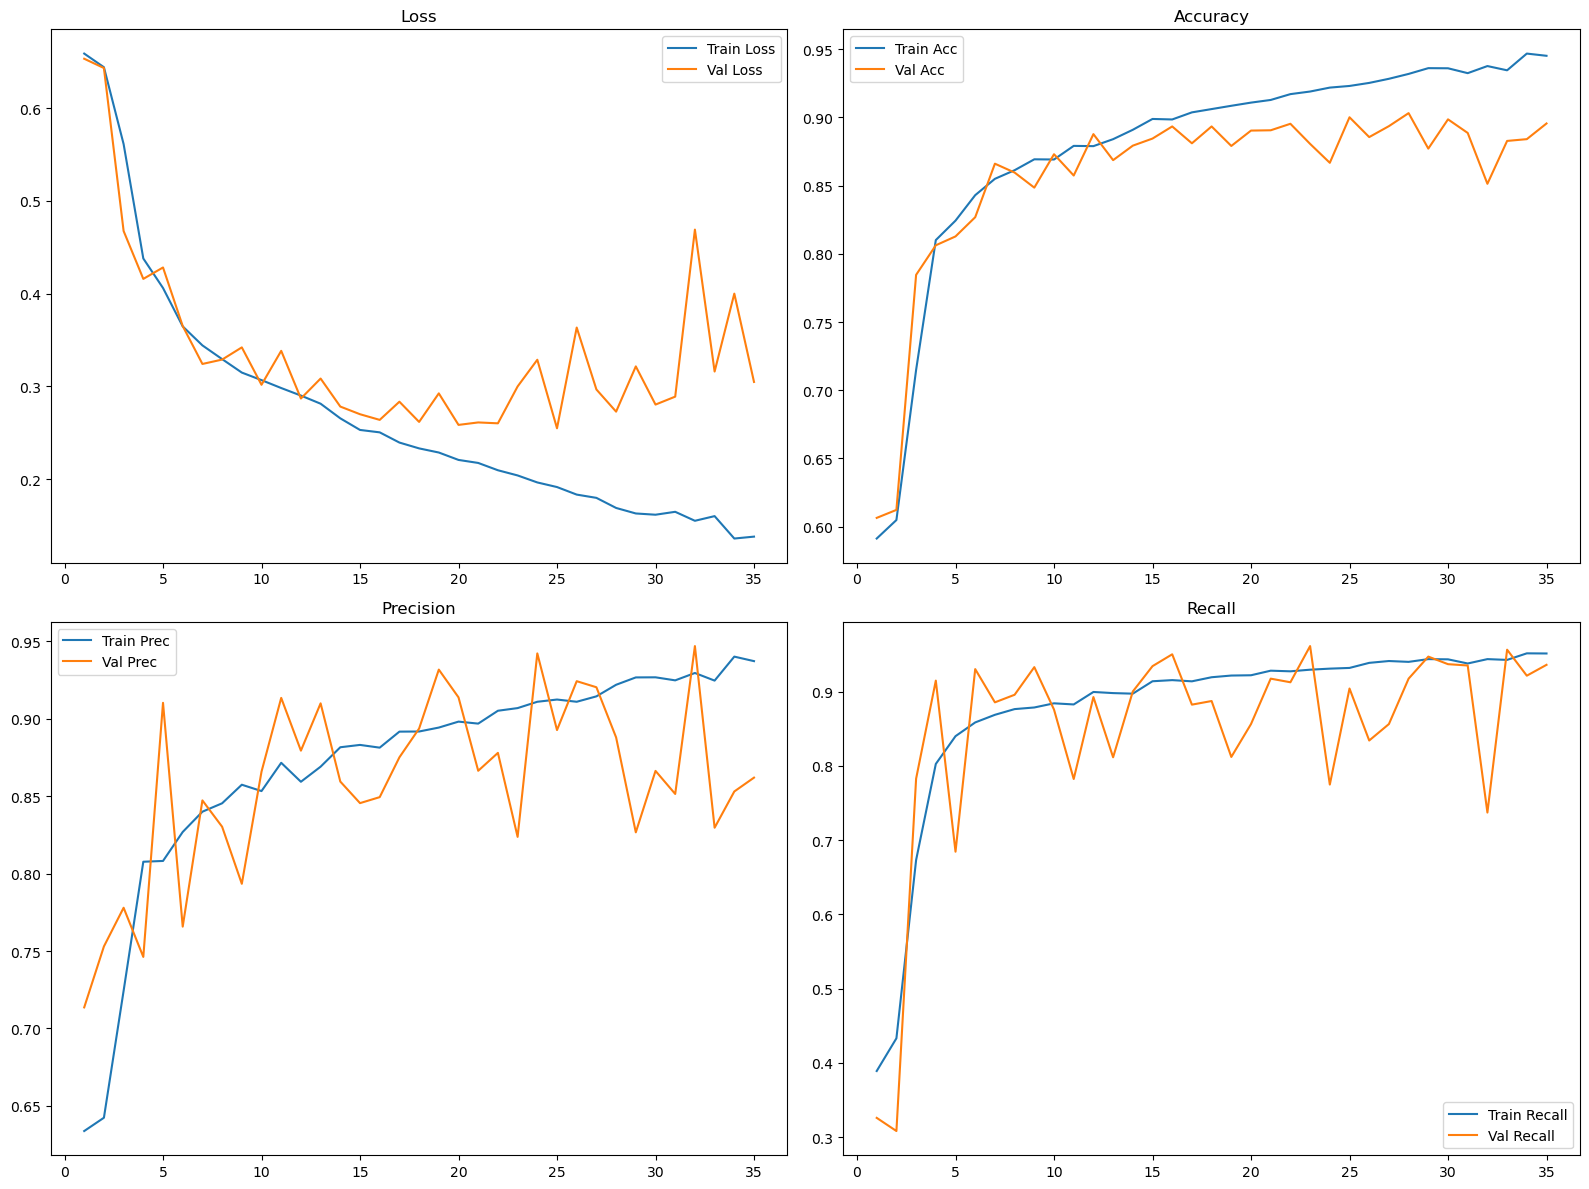

<Figure size 500x400 with 0 Axes>

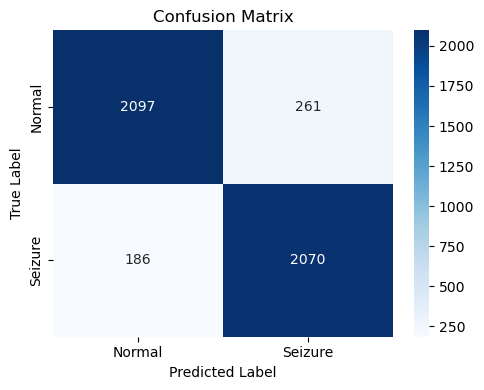

In [8]:
# 학습
model3 = train_model(model3, train_loader, val_loader,
                     criterion, optimizer, device,
                     num_epochs=epochs,
                     model_name="CNN_LSTM_Hybrid_Final",
                     save_model_dir=save_model_dir)


[TEST] CNN_LSTM_Hybrid_Final 결과

[Test Evaluation]
Accuracy  : 0.9027
Precision : 0.8660
Recall    : 0.9477
F1 Score  : 0.9050
Confusion Matrix:
 [[2027  331]
 [ 118 2139]]


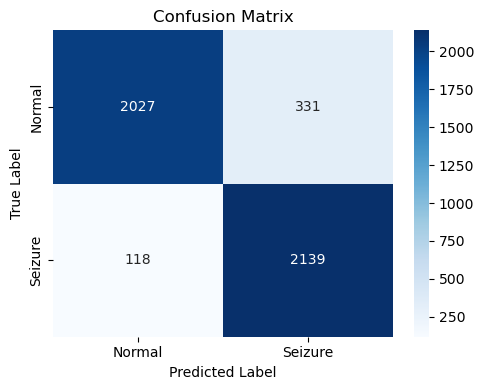

(0.9027085590465872, 0.8659919028340081, 0.9477182100132919, 0.905013750793315)

In [9]:
# 테스트
print("\n[TEST] CNN_LSTM_Hybrid_Final 결과")
evaluate_on_test(model3, test_loader, device)